In [25]:
import torch
import torch.nn as nn

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(UNet, self).__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Dropout2d(0.2),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
            )

        self.down1 = conv_block(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.down3 = conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.down4 = conv_block(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = conv_block(512, 1024)

        self.upconv4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.up4 = conv_block(1024, 512)
        self.upconv3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.up3 = conv_block(512, 256)
        self.upconv2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.up2 = conv_block(256, 128)
        self.upconv1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.up1 = conv_block(128, 64)

        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)
        d2 = self.down2(p1)
        p2 = self.pool2(d2)
        d3 = self.down3(p2)
        p3 = self.pool3(d3)
        d4 = self.down4(p3)
        p4 = self.pool4(d4)

        bn = self.bottleneck(p4)

        up4 = self.upconv4(bn)
        up4 = torch.cat([up4, d4], dim=1)
        up4 = self.up4(up4)

        up3 = self.upconv3(up4)
        up3 = torch.cat([up3, d3], dim=1)
        up3 = self.up3(up3)

        up2 = self.upconv2(up3)
        up2 = torch.cat([up2, d2], dim=1)
        up2 = self.up2(up2)

        up1 = self.upconv1(up2)
        up1 = torch.cat([up1, d1], dim=1)
        up1 = self.up1(up1)

        return self.final_conv(up1)


In [26]:
x = torch.randn(4, 1, 256, 256)  # (batch, channels, height, width)
model = UNet()
out = model(x)
print(out.shape)


torch.Size([4, 1, 256, 256])


In [27]:
class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, inputs, targets, smooth=1):
        inputs = torch.sigmoid(inputs)
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        intersection = (inputs * targets).sum()
        dice = (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)
        dice_loss = 1 - dice
        bce_loss = self.bce(inputs, targets)
        return bce_loss + dice_loss


In [28]:
from torch.utils.data import Dataset
import os
import cv2
import numpy as np
# import albumentations as A
# from albumentations.pytorch import ToTensorV2

class SegmentationDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform
        self.filenames = sorted(os.listdir(images_dir))

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.filenames[idx])
        mask_path = os.path.join(self.masks_dir, self.filenames[idx])

        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        image = image.astype(np.float32) / 255.0
        mask = mask.astype(np.float32) / 255.0

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        else:
            image = np.expand_dims(image, axis=0)
            mask = np.expand_dims(mask, axis=0)

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)


In [29]:
from torch.utils.data import DataLoader
import torch.optim as optim
# Paths
train_images_dir = 'C:/Users/Lenovo/Downloads/Arjun-dude/Brain_tumour/train/images'
train_masks_dir =  'C:/Users/Lenovo/Downloads/Arjun-dude/Brain_tumour/train/masks'
val_images_dir =  'C:/Users/Lenovo/Downloads/Arjun-dude/Brain_tumour/val/images'
val_masks_dir = 'C:/Users/Lenovo/Downloads/Arjun-dude/Brain_tumour/val/masks'

train_dataset = SegmentationDataset(train_images_dir, train_masks_dir)
val_dataset = SegmentationDataset(val_images_dir, val_masks_dir)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet().to(device)
criterion = DiceBCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

best_val_loss = float('inf')
patience = 10
counter = 0

for epoch in range(40):
    print(f"\nEpoch {epoch+1}/40")

    model.train()
    train_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    print(f"Train Loss: {avg_train_loss:.4f}")

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    print(f"Val Loss: {avg_val_loss:.4f}")
    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), 'unet_improved.pth')
        print("✅ Validation improved. Model saved.")
    else:
        counter += 1
        print(f"⏳ No improvement: {counter}/{patience}")
        if counter >= patience:
            print("🛑 Early stopping.")
            break

print("✅ Training complete.")




Epoch 1/40
Train Loss: 1.8054
Val Loss: 1.7726
✅ Validation improved. Model saved.

Epoch 2/40
Train Loss: 1.6905
Val Loss: 1.6157
✅ Validation improved. Model saved.

Epoch 3/40
Train Loss: 1.5934
Val Loss: 1.5049
✅ Validation improved. Model saved.

Epoch 4/40
Train Loss: 1.4850
Val Loss: 1.4181
✅ Validation improved. Model saved.

Epoch 5/40
Train Loss: 1.3686
Val Loss: 1.2747
✅ Validation improved. Model saved.

Epoch 6/40
Train Loss: 1.2526
Val Loss: 1.1948
✅ Validation improved. Model saved.

Epoch 7/40
Train Loss: 1.1675
Val Loss: 1.1161
✅ Validation improved. Model saved.

Epoch 8/40
Train Loss: 1.1037
Val Loss: 1.0331
✅ Validation improved. Model saved.

Epoch 9/40
Train Loss: 1.0578
Val Loss: 1.0539
⏳ No improvement: 1/10

Epoch 10/40
Train Loss: 1.0330
Val Loss: 1.0371
⏳ No improvement: 2/10

Epoch 11/40
Train Loss: 1.0011
Val Loss: 1.0187
✅ Validation improved. Model saved.

Epoch 12/40
Train Loss: 0.9906
Val Loss: 0.9805
✅ Validation improved. Model saved.

Epoch 13/40
Tr

In [30]:
import torch

# Define your UNet model class again (or import it if you have it in another file)
model = UNet()  # Make sure UNet() matches the model you trained
model.load_state_dict(torch.load('./unet_improved.pth'))
model.eval()  # Set the model to evaluation mode
print("✅ Model loaded from 'unet_improved.pth'")


✅ Model loaded from 'unet_improved.pth'


In [36]:
def compute_metrics(preds, targets, threshold=0.5, smooth=1e-6):
    preds = torch.sigmoid(preds) > threshold
    preds = preds.float()
    targets = targets.float()

    intersection = (preds * targets).sum(dim=(1,2,3))
    union = preds.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))

    dice = (2 * intersection + smooth) / (union + smooth)
    iou = (intersection + smooth) / ((preds + targets).sum(dim=(1,2,3)) - intersection + smooth)
    precision = (preds * targets).sum(dim=(1,2,3)) / (preds.sum(dim=(1,2,3)) + smooth)
    recall = (preds * targets).sum(dim=(1,2,3)) / (targets.sum(dim=(1,2,3)) + smooth)

    return dice, precision, recall, iou

def evaluate_model(model, dataloader, device, name="Data"):
    model.eval()
    dice_scores, precision_scores, recall_scores, iou_scores = [], [], [], []

    with torch.no_grad():
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            dice, precision, recall, iou = compute_metrics(outputs, masks)
            dice_scores.append(dice.mean())
            precision_scores.append(precision.mean())
            recall_scores.append(recall.mean())
            iou_scores.append(iou.mean())

    print(f"Dice Coefficient: {torch.stack(dice_scores).mean().item():.4f}")
    print(f"Precision: {torch.stack(precision_scores).mean().item():.4f}")
    print(f"Recall: {torch.stack(recall_scores).mean().item():.4f}")
    print(f"IoU: {torch.stack(iou_scores).mean().item():.4f}")

# Call after training completes
model.to(device)

evaluate_model(model, train_loader, device, name="Train Data")


Dice Coefficient: 0.8479
Precision: 0.8457
Recall: 0.8658
IoU: 0.7747


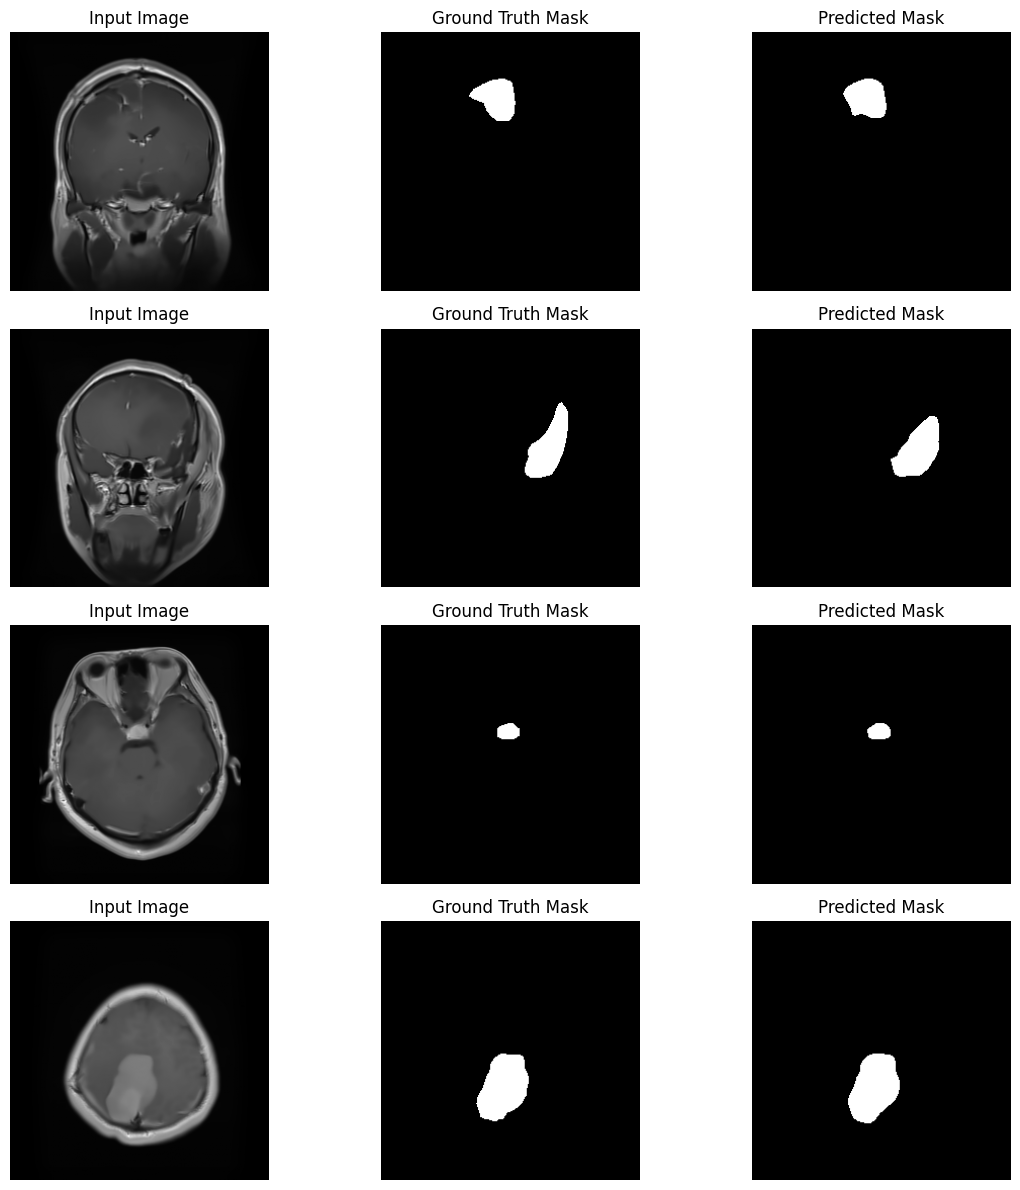

In [37]:
import matplotlib.pyplot as plt
import random

def visualize_random_train_batch(model, dataloader, device, num_samples=4):
    model.eval()
    images, masks = next(iter(dataloader))
    images, masks = images.to(device), masks.to(device)

    with torch.no_grad():
        outputs = torch.sigmoid(model(images))
        preds = (outputs > 0.5).float()

    indices = random.sample(range(images.shape[0]), num_samples)
    fig, axs = plt.subplots(num_samples, 3, figsize=(12, 3 * num_samples))

    for i, idx in enumerate(indices):
        img = images[idx].cpu().squeeze().numpy()
        gt_mask = masks[idx].cpu().squeeze().numpy()
        pred_mask = preds[idx].cpu().squeeze().numpy()

        axs[i, 0].imshow(img, cmap='gray')
        axs[i, 0].set_title("Input Image")
        axs[i, 1].imshow(gt_mask, cmap='gray')
        axs[i, 1].set_title("Ground Truth Mask")
        axs[i, 2].imshow(pred_mask, cmap='gray')
        axs[i, 2].set_title("Predicted Mask")

        for j in range(3):
            axs[i, j].axis('off')

    plt.tight_layout()
    plt.show()
visualize_random_train_batch(model, train_loader, device)